# Spam link detection system

In [75]:
import pandas as pd
import regex as re
import matplotlib.pyplot as plt
from nltk import download
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from pickle import dump
import warnings
warnings.filterwarnings("ignore")

## Importing Data

In [45]:
df = pd.read_csv(r"C:\Users\USER\Desktop\PROYECTOS\josefina-aispuro-merelles-machine-learning\data\raw\url_spam.csv.csv")
df

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True
...,...,...
2994,https://www.smartcitiesworld.net/news/news/dee...,False
2995,https://www.youtube.com/watch,True
2996,https://techcrunch.com/2019/07/04/an-optimisti...,False
2997,https://www.technologyreview.com/2019/12/20/13...,False


## Processing Data

In [46]:
# Convert the target variable from boolean (True/False) to binary values (1 for spam, 0 for non-spam)
df["is_spam"] = df["is_spam"].astype(int)
df

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,1
1,https://www.hvper.com/,1
2,https://briefingday.com/m/v4n3i4f3,1
3,https://briefingday.com/n/20200618/m#commentform,0
4,https://briefingday.com/fan,1
...,...,...
2994,https://www.smartcitiesworld.net/news/news/dee...,0
2995,https://www.youtube.com/watch,1
2996,https://techcrunch.com/2019/07/04/an-optimisti...,0
2997,https://www.technologyreview.com/2019/12/20/13...,0


In [47]:
# Display the data type of each column in the DataFrame
df.dtypes

url        object
is_spam     int32
dtype: object

In [48]:
# Show the dimensions of the DataFrame (number of rows and columns)
df.shape

(2999, 2)

In [49]:
# Dropping duplicates if True
if df.duplicated().sum():
        df = df.drop_duplicates()
        
df

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,1
1,https://www.hvper.com/,1
2,https://briefingday.com/m/v4n3i4f3,1
3,https://briefingday.com/n/20200618/m#commentform,0
4,https://briefingday.com/fan,1
...,...,...
2993,https://www.theverge.com/2020/6/29/21306889/di...,0
2994,https://www.smartcitiesworld.net/news/news/dee...,0
2996,https://techcrunch.com/2019/07/04/an-optimisti...,0
2997,https://www.technologyreview.com/2019/12/20/13...,0


### Observations
- We have two columns: one object (categorical/text) column and one numerical column.
- We dropped 630 duplicated rows.
- We ended up with 2369 rows.
- Our target column has been converted from a boolean variable to a numerical one.

## Data Cleaning

In [50]:
# Define a function to preprocess URLs
def preprocess_url(url):
    # Convert to lowercase
    url = url.lower()
    
    # Replace URL separators and special characters with spaces
    url = re.sub(r"[\/\.\-\_\?\=\&\:\#]", " ", url)
    
    # Remove single characters
    url = re.sub(r"\s+[a-zA-Z]\s+", " ", url)
    
    # Remove extra white spaces
    url = re.sub(r"\s+", " ", url)
    
    return url.split()

In [51]:
# Apply function to our df
df["url"] = df["url"].apply(preprocess_url)

In [52]:
# Download WordNet for lemmatization
download("wordnet")

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [53]:
# Download English stopwords
download("stopwords")

# Load stopwords into a list
stop_words = stopwords.words("english")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [54]:
# Define a function to lemmatize words and remove stopwords
def lemmatize_text(words, lemmatizer=lemmatizer):
    # Apply lemmatization to each word
    tokens = [lemmatizer.lemmatize(word) for word in words]
    
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    # Remove very short words (less than 4 characters)
    tokens = [word for word in tokens if len(word) > 3]
    
    # Return the cleaned and lemmatized tokens
    return tokens

In [55]:
# Apply function to our df
df["url"] = df["url"].apply(lemmatize_text)

In [56]:
# Convert each list of tokens back to a string for WordCloud and TF-IDF
url_strings = [" ".join(tokens) for tokens in df["url"]]

In [57]:
# Checking df
df.head()

,url,is_spam
0,"[http, briefingday, list, manage, unsubscribe]",1
1,"[http, hvper]",1
2,"[http, briefingday, v4n3i4f3]",1
3,"[http, briefingday, 20200618, commentform]",0
4,"[http, briefingday]",1


In [58]:
# Generate a WordCloud from the processed URLs
wordcloud = WordCloud(width=800, height=800, background_color="black", max_words=1000, min_font_size=20, random_state=42).generate(" ".join(url_strings))

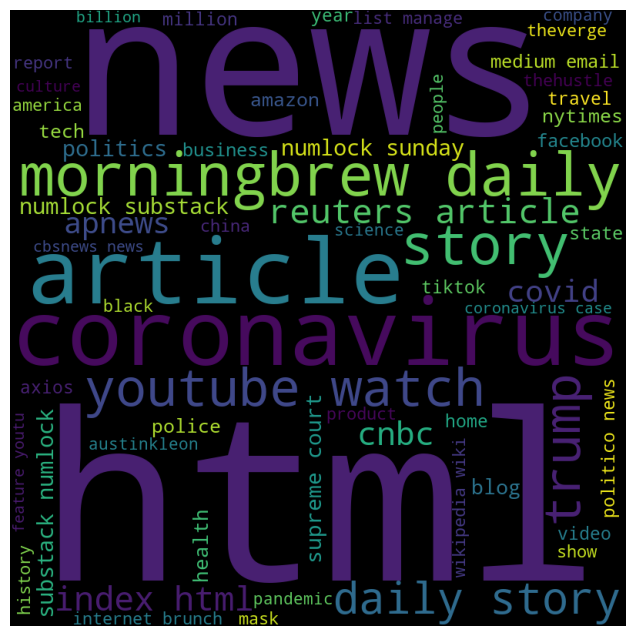

In [ ]:
# Plotting the WordCloud
fig = plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [60]:
# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=5000, max_df=0.8, min_df=5)

In [61]:
# Transform URLs into numerical features
X = vectorizer.fit_transform(url_strings).toarray()
y = df["is_spam"]

In [62]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Training model and making predictions

In [63]:
# Initialize and train a linear SVM
svm_model = SVC(kernel="linear", random_state=42)
svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [64]:
# Predict on test set
y_pred = svm_model.predict(X_test)

In [74]:
# Calculate accuracy of the SVM
accuracy_score(y_test, y_pred)

0.9578059071729957

### Observations
The SVM model achieved an accuracy of 95.78%, indicating that it correctly classified the majority of URLs as spam or not spam. This suggests that the preprocessing and feature extraction steps were effective in capturing the relevant patterns for spam detection

## Model Optimization

In [66]:
# Define hyperparameters grid for optimization
param_grid = {"C": [0.1, 1, 10, 100], "kernel": ["linear", "poly", "rbf"], "degree": [2, 3, 4], "gamma": ["scale", "auto"]}

In [69]:
# Initialize grid search for SVM
grid_search = GridSearchCV(svm_model, param_grid, scoring="accuracy", cv=5)
grid_search.fit(X_train, y_train)

,estimator,SVC(kernel='l...ndom_state=42)
,param_grid,"{'C': [0.1, 1, ...], 'degree': [2, 3, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'poly', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [71]:
# Best hyperparameters found
grid_search.best_params_

{'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}

In [72]:
# Train optimized SVM with best parameters
opt_model = SVC(C=1000, degree=1, gamma="auto", kernel="poly", random_state=42)
opt_model.fit(X_train, y_train)

,C,1000
,kernel,'poly'
,degree,1
,gamma,'auto'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [73]:
# Predict and evaluate optimized model
y_pred_opt = opt_model.predict(X_test)
accuracy_score(y_test, y_pred_opt)

0.9556962025316456

### Conclusion
The original SVM model achieved an accuracy of 95.78%, while the optimized SVM model reached 95.57%. The optimized model did not improve performance, so we will save the original model since it performs slightly better.

## Saving model

In [76]:
# Save the original SVM model to a file
dump(svm_model, open("svm_original_model.pkl", "wb"))